# Round 5 — group-wise time series analysis

For each of the 10 product groups (5 members each), this notebook:

1. Plots the mid-price time series of every member.
2. Computes the pairwise correlation matrix of mid-price levels and of returns.
3. Tests every pairwise spread within the group for stationarity (Augmented Dickey-Fuller, p < 0.05 ⇒ stationary).
4. Surfaces the most cointegration-friendly pairs (lowest ADF p-value, highest level-correlation).

Groups: GALAXY_SOUNDS, MICROCHIP, OXYGEN_SHAKE, PANEL, PEBBLES, ROBOT, SLEEP_POD, SNACKPACK, TRANSLATOR, UV_VISOR.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')

DATA_DIR = 'data'
DAYS = [2, 3, 4]

## 1. Load data

In [2]:
def load_prices(days=DAYS, data_dir=DATA_DIR):
    frames = []
    for d in days:
        df = pd.read_csv(os.path.join(data_dir, f'prices_round_5_day_{d}.csv'), sep=';')
        df['day'] = d
        frames.append(df)
    p = pd.concat(frames, ignore_index=True)
    p['t'] = (p['day'] - DAYS[0]) * 1_000_000 + p['timestamp']
    return p.sort_values(['t', 'product']).reset_index(drop=True)

def load_trades(days=DAYS, data_dir=DATA_DIR):
    frames = []
    for d in days:
        df = pd.read_csv(os.path.join(data_dir, f'trades_round_5_day_{d}.csv'), sep=';')
        df['day'] = d
        frames.append(df)
    t = pd.concat(frames, ignore_index=True)
    t['t'] = (t['day'] - DAYS[0]) * 1_000_000 + t['timestamp']
    return t.sort_values('t').reset_index(drop=True)

prices = load_prices()
trades = load_trades()
print('prices:', prices.shape, '| trades:', trades.shape)
print('products:', prices['product'].nunique())

prices: (1500000, 18) | trades: (35385, 9)
products: 50


## 2. Group definitions and wide mid-price panel

In [3]:
GROUPS = {
    'GALAXY_SOUNDS': ['GALAXY_SOUNDS_BLACK_HOLES', 'GALAXY_SOUNDS_DARK_MATTER',
                     'GALAXY_SOUNDS_PLANETARY_RINGS', 'GALAXY_SOUNDS_SOLAR_FLAMES',
                     'GALAXY_SOUNDS_SOLAR_WINDS'],
    'MICROCHIP':    ['MICROCHIP_CIRCLE', 'MICROCHIP_OVAL', 'MICROCHIP_RECTANGLE',
                     'MICROCHIP_SQUARE', 'MICROCHIP_TRIANGLE'],
    'OXYGEN_SHAKE': ['OXYGEN_SHAKE_CHOCOLATE', 'OXYGEN_SHAKE_EVENING_BREATH',
                     'OXYGEN_SHAKE_GARLIC', 'OXYGEN_SHAKE_MINT',
                     'OXYGEN_SHAKE_MORNING_BREATH'],
    'PANEL':        ['PANEL_1X2', 'PANEL_1X4', 'PANEL_2X2', 'PANEL_2X4', 'PANEL_4X4'],
    'PEBBLES':      ['PEBBLES_L', 'PEBBLES_M', 'PEBBLES_S', 'PEBBLES_XL', 'PEBBLES_XS'],
    'ROBOT':        ['ROBOT_DISHES', 'ROBOT_IRONING', 'ROBOT_LAUNDRY',
                     'ROBOT_MOPPING', 'ROBOT_VACUUMING'],
    'SLEEP_POD':    ['SLEEP_POD_COTTON', 'SLEEP_POD_LAMB_WOOL', 'SLEEP_POD_NYLON',
                     'SLEEP_POD_POLYESTER', 'SLEEP_POD_SUEDE'],
    'SNACKPACK':    ['SNACKPACK_CHOCOLATE', 'SNACKPACK_PISTACHIO', 'SNACKPACK_RASPBERRY',
                     'SNACKPACK_STRAWBERRY', 'SNACKPACK_VANILLA'],
    'TRANSLATOR':   ['TRANSLATOR_ASTRO_BLACK', 'TRANSLATOR_ECLIPSE_CHARCOAL',
                     'TRANSLATOR_GRAPHITE_MIST', 'TRANSLATOR_SPACE_GRAY',
                     'TRANSLATOR_VOID_BLUE'],
    'UV_VISOR':     ['UV_VISOR_AMBER', 'UV_VISOR_MAGENTA', 'UV_VISOR_ORANGE',
                     'UV_VISOR_RED', 'UV_VISOR_YELLOW'],
}
assert sum(len(v) for v in GROUPS.values()) == 50
mid = (
    prices.pivot_table(index='t', columns='product', values='mid_price', aggfunc='last')
          .sort_index()
          .ffill()
)
print('mid panel:', mid.shape, '(rows = ticks, cols = products)')
mid.head(3)

mid panel: (30000, 50) (rows = ticks, cols = products)


product,GALAXY_SOUNDS_BLACK_HOLES,GALAXY_SOUNDS_DARK_MATTER,GALAXY_SOUNDS_PLANETARY_RINGS,GALAXY_SOUNDS_SOLAR_FLAMES,GALAXY_SOUNDS_SOLAR_WINDS,MICROCHIP_CIRCLE,MICROCHIP_OVAL,MICROCHIP_RECTANGLE,MICROCHIP_SQUARE,MICROCHIP_TRIANGLE,...,TRANSLATOR_ASTRO_BLACK,TRANSLATOR_ECLIPSE_CHARCOAL,TRANSLATOR_GRAPHITE_MIST,TRANSLATOR_SPACE_GRAY,TRANSLATOR_VOID_BLUE,UV_VISOR_AMBER,UV_VISOR_MAGENTA,UV_VISOR_ORANGE,UV_VISOR_RED,UV_VISOR_YELLOW
t,,,,,,,,,,,,,,,,,,,,,
0,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,...,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000
100,10007.5000,9988.5000,9988.5000,10002.5000,10000.5000,9991.5000,9999.5000,9999.5000,9999.5000,10000.5000,...,9986.5000,10015.5000,10006.5000,10000.5000,10002.5000,10014.0000,10009.5000,10003.5000,10004.5000,9989.5000
200,10002.5000,10003.5000,9995.5000,10003.5000,10007.5000,9993.5000,9998.5000,10001.5000,9999.5000,10001.5000,...,9996.5000,9996.5000,10002.5000,10002.5000,10007.5000,10003.5000,10017.5000,10016.5000,10017.5000,9985.5000


## 3. Per-product diagnostics (single time series)

Quick stats for every product so we can spot the obviously different ones before grouping.

In [4]:
log_ret = np.log(mid).diff()

per_prod = pd.DataFrame({
    'mean':       mid.mean(),
    'std':        mid.std(),
    'min':        mid.min(),
    'max':        mid.max(),
    'ret_std':    log_ret.std(),
    'ret_skew':   log_ret.skew(),
    'ret_kurt':   log_ret.kurt(),
})
per_prod['group'] = [next(g for g, ms in GROUPS.items() if p in ms) for p in per_prod.index]
per_prod = per_prod.sort_values(['group', 'mean'])
per_prod

,mean,std,min,max,ret_std,ret_skew,ret_kurt,group
product,,,,,,,,
GALAXY_SOUNDS_DARK_MATTER,10226.6618,330.7005,9541.0000,11186.0000,0.0010,-0.0184,-0.0107,GALAXY_SOUNDS
GALAXY_SOUNDS_SOLAR_WINDS,10437.5440,541.1108,9320.0000,11613.5000,0.0010,0.0031,0.0190,GALAXY_SOUNDS
GALAXY_SOUNDS_PLANETARY_RINGS,10766.6732,765.8367,9253.0000,12182.0000,0.0010,0.0172,0.0082,GALAXY_SOUNDS
GALAXY_SOUNDS_SOLAR_FLAMES,11092.5717,450.1504,9837.5000,12210.0000,0.0010,0.0063,-0.0071,GALAXY_SOUNDS
GALAXY_SOUNDS_BLACK_HOLES,11466.8721,958.4447,9608.5000,14137.0000,0.0010,0.0033,0.0384,GALAXY_SOUNDS
MICROCHIP_OVAL,8179.5987,1551.9116,5375.0000,10433.0000,0.0015,-0.0133,0.0657,MICROCHIP
MICROCHIP_RECTANGLE,8732.4394,752.0193,7327.5000,10442.5000,0.0015,0.0077,-0.0022,MICROCHIP
MICROCHIP_CIRCLE,9214.8853,532.5122,8303.5000,10731.5000,0.0010,-0.0215,0.0159,MICROCHIP
MICROCHIP_TRIANGLE,9686.3911,833.3696,7749.0000,10872.0000,0.0015,0.0102,0.0137,MICROCHIP


## 4. Per-group analysis function

For one group: line-plot, level-correlation heatmap, return-correlation heatmap, and pairwise ADF stationarity test on price spreads.

In [5]:
# Dickey-Fuller critical values (constant only, no trend), large-sample
DF_CRIT = {0.01: -3.43, 0.05: -2.86, 0.10: -2.57}

def adf_test(series, max_lag=4):
    """Pure-numpy ADF with constant. Returns (t_stat, approx_p, n_obs).

    Regression: dy_t = alpha + beta*y_{t-1} + sum_i gamma_i * dy_{t-i} + eps
    Lag count chosen by AIC up to max_lag. p-value is interpolated from
    Dickey-Fuller critical values (sufficient for our 5% threshold)."""
    s = np.asarray(series.dropna(), dtype=float)
    n = len(s)
    if n < 30 or np.std(s) == 0:
        return np.nan, np.nan, n
    dy = np.diff(s)
    y_lag = s[:-1]
    best = None
    for k in range(0, max_lag + 1):
        if len(dy) - k < 10:
            break
        Y = dy[k:]
        X_cols = [np.ones_like(Y), y_lag[k:]]
        for j in range(1, k + 1):
            X_cols.append(dy[k - j: -j] if j != 0 else dy[k:])
        X = np.column_stack(X_cols)
        try:
            coef, resid, rank, sv = np.linalg.lstsq(X, Y, rcond=None)
        except np.linalg.LinAlgError:
            continue
        n_obs = len(Y); k_params = X.shape[1]
        if n_obs <= k_params:
            continue
        e = Y - X @ coef
        sse = float(e @ e)
        sigma2 = sse / (n_obs - k_params)
        try:
            cov = sigma2 * np.linalg.inv(X.T @ X)
        except np.linalg.LinAlgError:
            continue
        se_beta = float(np.sqrt(cov[1, 1]))
        t_stat = float(coef[1] / se_beta) if se_beta > 0 else np.nan
        aic = n_obs * np.log(sse / n_obs) + 2 * k_params
        if best is None or aic < best[0]:
            best = (aic, t_stat, n_obs)
    if best is None:
        return np.nan, np.nan, n
    _, t_stat, n_obs = best
    # Interpolate p-value from DF critical values
    if t_stat <= DF_CRIT[0.01]:
        p = 0.005
    elif t_stat <= DF_CRIT[0.05]:
        # between 1% and 5%
        frac = (t_stat - DF_CRIT[0.01]) / (DF_CRIT[0.05] - DF_CRIT[0.01])
        p = 0.01 + frac * (0.05 - 0.01)
    elif t_stat <= DF_CRIT[0.10]:
        frac = (t_stat - DF_CRIT[0.05]) / (DF_CRIT[0.10] - DF_CRIT[0.05])
        p = 0.05 + frac * (0.10 - 0.05)
    else:
        # very rough mapping above 10% — use normal CDF as a stand-in
        p = max(0.10, 1.0 - stats.norm.cdf(-t_stat))
    return t_stat, p, n_obs

def adf_pvalue(series):
    _, p, _ = adf_test(series)
    return p

def analyse_group(group_name, members, mid, log_ret):
    sub_mid = mid[members].dropna()
    sub_ret = log_ret[members].dropna()

    # ---- Plot price levels (normalized to first obs for shape comparison) ----
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    norm = sub_mid / sub_mid.iloc[0]
    norm.plot(ax=axes[0], lw=0.7)
    axes[0].set_title(f'{group_name}: normalized mid-price (start=1)')
    axes[0].set_xlabel('t'); axes[0].set_ylabel('rel. price')

    # ---- Correlation heatmaps ----
    lvl_corr = sub_mid.corr()
    ret_corr = sub_ret.corr()
    sns.heatmap(lvl_corr, annot=True, fmt='.3f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, ax=axes[1], cbar=False)
    axes[1].set_title(f'{group_name}: level correlation')
    sns.heatmap(ret_corr, annot=True, fmt='.3f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, ax=axes[2], cbar=False)
    axes[2].set_title(f'{group_name}: log-return correlation')
    for ax in axes[1:]:
        ax.tick_params(axis='x', rotation=45)
    plt.tight_layout(); plt.show()

    # ---- Pairwise spreads + ADF ----
    rows = []
    for i, a in enumerate(members):
        for b in members[i+1:]:
            spread = sub_mid[a] - sub_mid[b]
            log_spread = np.log(sub_mid[a]) - np.log(sub_mid[b])
            rows.append({
                'a': a, 'b': b,
                'level_corr':    lvl_corr.loc[a, b],
                'ret_corr':      ret_corr.loc[a, b],
                'spread_mean':   float(spread.mean()),
                'spread_std':    float(spread.std()),
                'spread_adf_p':  adf_pvalue(spread),
                'logspread_adf_p': adf_pvalue(log_spread),
            })
    pairs = pd.DataFrame(rows)
    pairs['stationary_5pct'] = pairs['spread_adf_p'] < 0.05
    pairs = pairs.sort_values('spread_adf_p').reset_index(drop=True)
    return pairs, lvl_corr, ret_corr

## 5. Run analysis on every group

For each group we render the three plots, then print the pair table sorted by ADF p-value (most stationary first).


=== GALAXY_SOUNDS ===


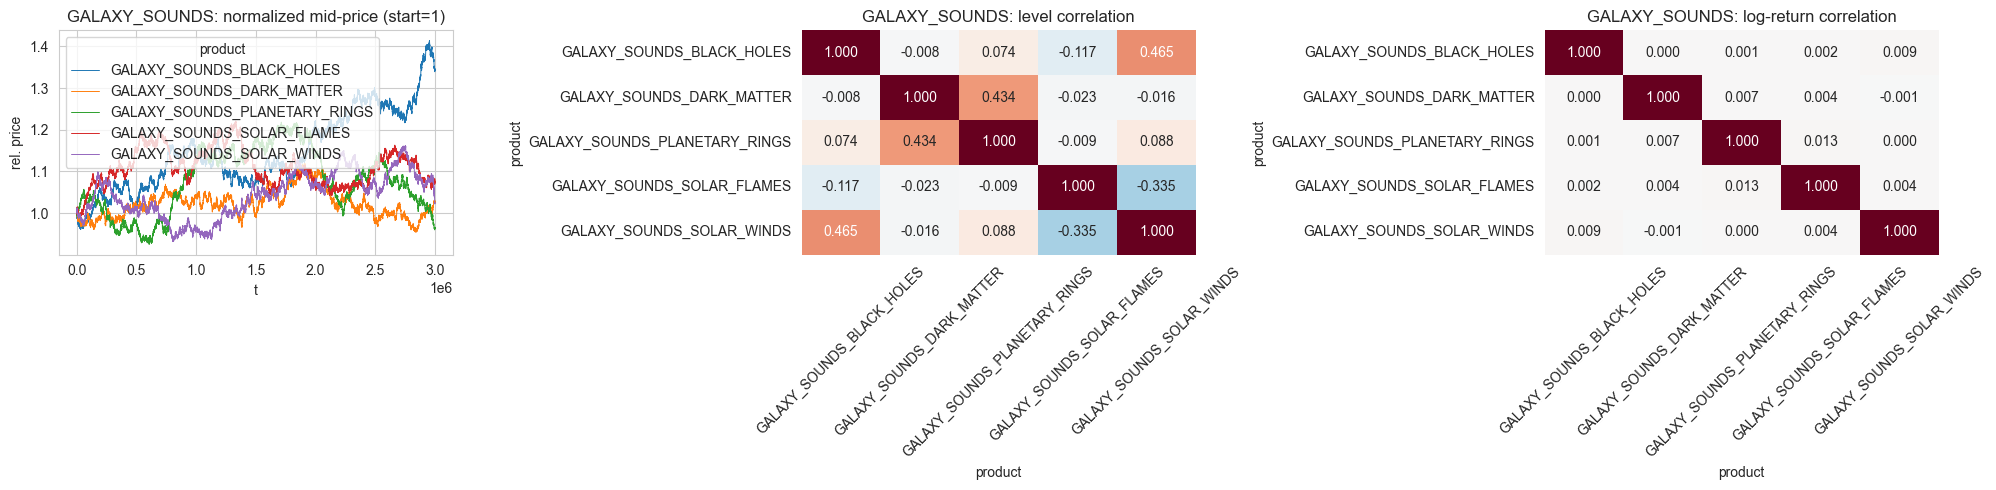

                            a                             b  level_corr  ret_corr  spread_mean  spread_std  spread_adf_p  logspread_adf_p  stationary_5pct
    GALAXY_SOUNDS_DARK_MATTER GALAXY_SOUNDS_PLANETARY_RINGS      0.4342    0.0074    -540.0114    689.8766        0.1000           0.1000            False
    GALAXY_SOUNDS_DARK_MATTER    GALAXY_SOUNDS_SOLAR_FLAMES     -0.0225    0.0045    -865.9099    564.5415        0.1000           0.0987            False
    GALAXY_SOUNDS_DARK_MATTER     GALAXY_SOUNDS_SOLAR_WINDS     -0.0157   -0.0013    -210.8821    638.5732        0.1000           0.1000            False
GALAXY_SOUNDS_PLANETARY_RINGS    GALAXY_SOUNDS_SOLAR_FLAMES     -0.0091    0.0130    -325.8985    891.8662        0.1000           0.1000            False
GALAXY_SOUNDS_PLANETARY_RINGS     GALAXY_SOUNDS_SOLAR_WINDS      0.0876    0.0002     329.1292    898.1684        0.1000           0.1000            False
   GALAXY_SOUNDS_SOLAR_FLAMES     GALAXY_SOUNDS_SOLAR_WINDS     -0.335

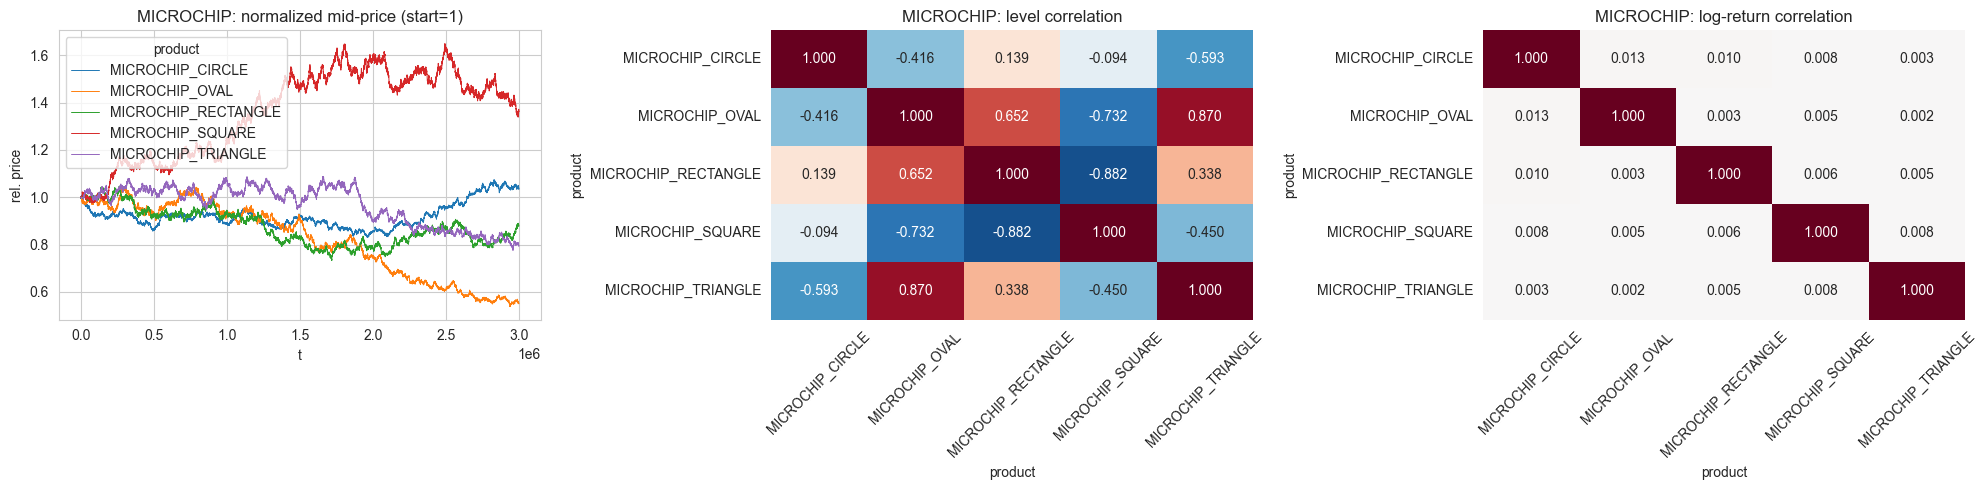

                  a                   b  level_corr  ret_corr  spread_mean  spread_std  spread_adf_p  logspread_adf_p  stationary_5pct
   MICROCHIP_CIRCLE MICROCHIP_RECTANGLE      0.1385    0.0102     482.4459    859.1625        0.1000           0.1000            False
   MICROCHIP_CIRCLE    MICROCHIP_SQUARE     -0.0938    0.0076   -4379.8630   1953.5173        0.1000           0.1000            False
     MICROCHIP_OVAL    MICROCHIP_SQUARE     -0.7317    0.0049   -5415.1496   3148.7510        0.1000           0.1369            False
     MICROCHIP_OVAL  MICROCHIP_TRIANGLE      0.8705    0.0018   -1506.7924    922.7015        0.1000           0.1000            False
MICROCHIP_RECTANGLE    MICROCHIP_SQUARE     -0.8823    0.0062   -4862.3089   2518.7538        0.1000           0.1000            False
MICROCHIP_RECTANGLE  MICROCHIP_TRIANGLE      0.3385    0.0053    -953.9517    914.2049        0.1000           0.1000            False
   MICROCHIP_SQUARE  MICROCHIP_TRIANGLE     -0.4505    

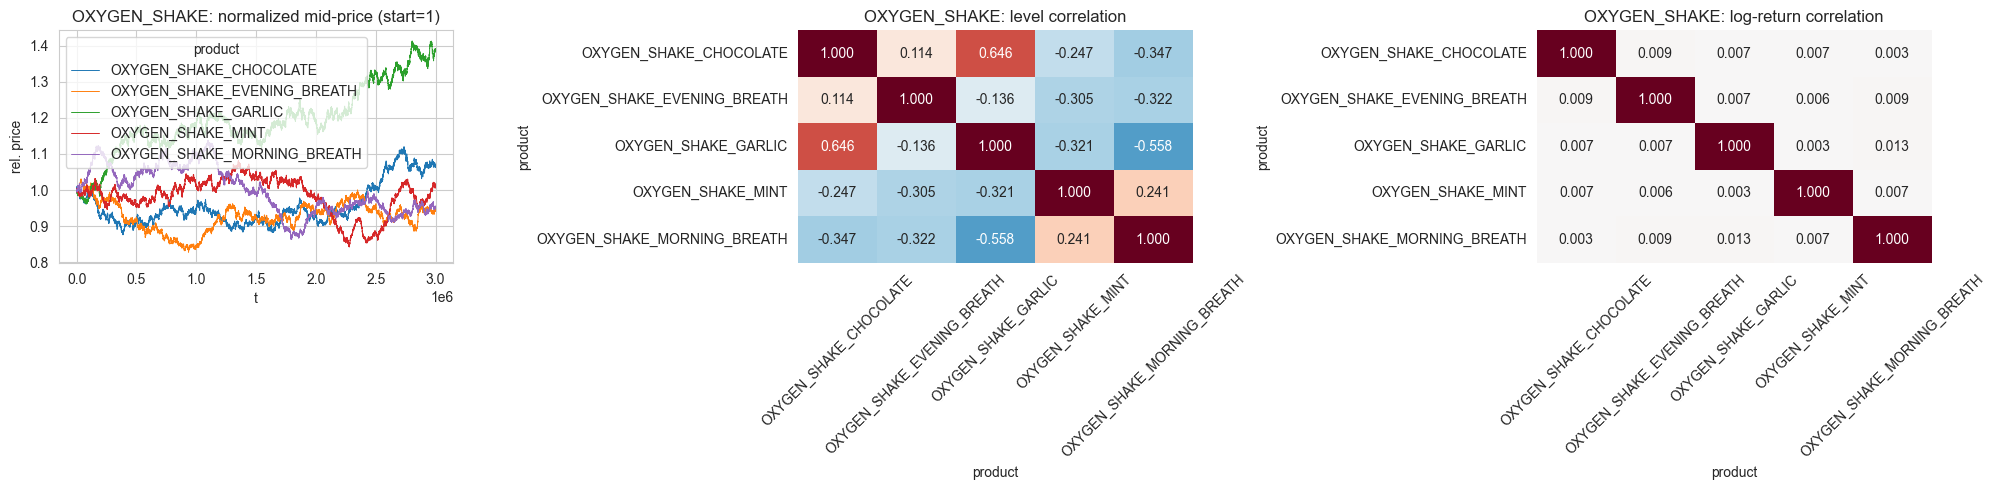

                          a                           b  level_corr  ret_corr  spread_mean  spread_std  spread_adf_p  logspread_adf_p  stationary_5pct
     OXYGEN_SHAKE_CHOCOLATE         OXYGEN_SHAKE_GARLIC      0.6458    0.0067   -2368.7606    729.9668        0.0342           0.0147             True
     OXYGEN_SHAKE_CHOCOLATE OXYGEN_SHAKE_EVENING_BREATH      0.1138    0.0091     284.9841    650.4747        0.1000           0.1000            False
OXYGEN_SHAKE_EVENING_BREATH         OXYGEN_SHAKE_GARLIC     -0.1358    0.0068   -2653.7448   1082.7039        0.1000           0.1000            False
OXYGEN_SHAKE_EVENING_BREATH           OXYGEN_SHAKE_MINT     -0.3053    0.0055    -566.4991    736.2753        0.1000           0.1000            False
OXYGEN_SHAKE_EVENING_BREATH OXYGEN_SHAKE_MORNING_BREATH     -0.3216    0.0090    -728.5584    868.2625        0.1000           0.1000            False
        OXYGEN_SHAKE_GARLIC           OXYGEN_SHAKE_MINT     -0.3210    0.0034    2087.2457   1

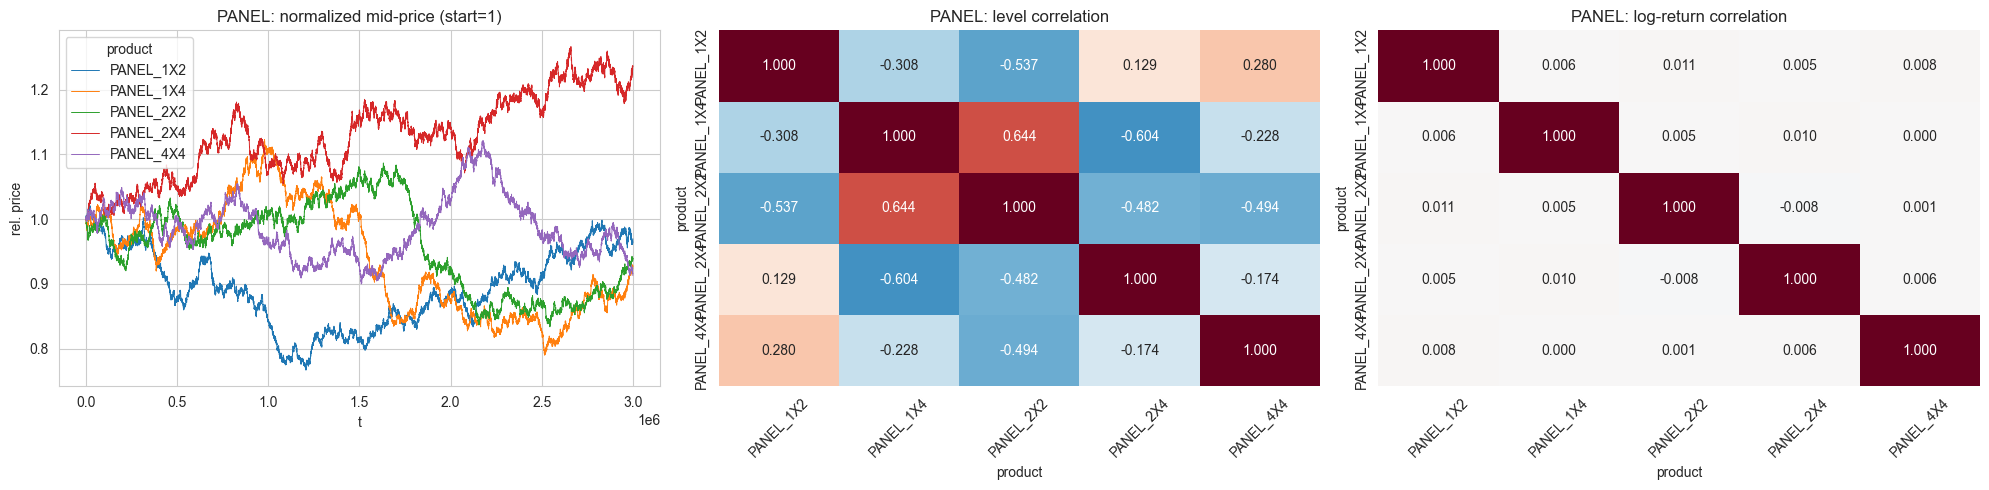

        a         b  level_corr  ret_corr  spread_mean  spread_std  spread_adf_p  logspread_adf_p  stationary_5pct
PANEL_1X2 PANEL_2X4      0.1286    0.0046   -2342.6440    803.8706        0.0460           0.0498             True
PANEL_1X2 PANEL_4X4      0.2801    0.0084    -955.9902    637.0816        0.1000           0.1000            False
PANEL_1X4 PANEL_2X2      0.6443    0.0055    -179.0178    652.4907        0.1000           0.1000            False
PANEL_2X2 PANEL_2X4     -0.4819   -0.0083   -1688.7746   1121.0071        0.1000           0.1000            False
PANEL_1X4 PANEL_2X4     -0.6041    0.0104   -1867.7924   1311.8744        0.1064           0.1000            False
PANEL_2X4 PANEL_4X4     -0.1745    0.0059    1386.6537    838.0218        0.1072           0.1065            False
PANEL_2X2 PANEL_4X4     -0.4941    0.0012    -302.1208    984.3678        0.1255           0.1237            False
PANEL_1X4 PANEL_4X4     -0.2279    0.0004    -481.1386   1038.3855        0.1337

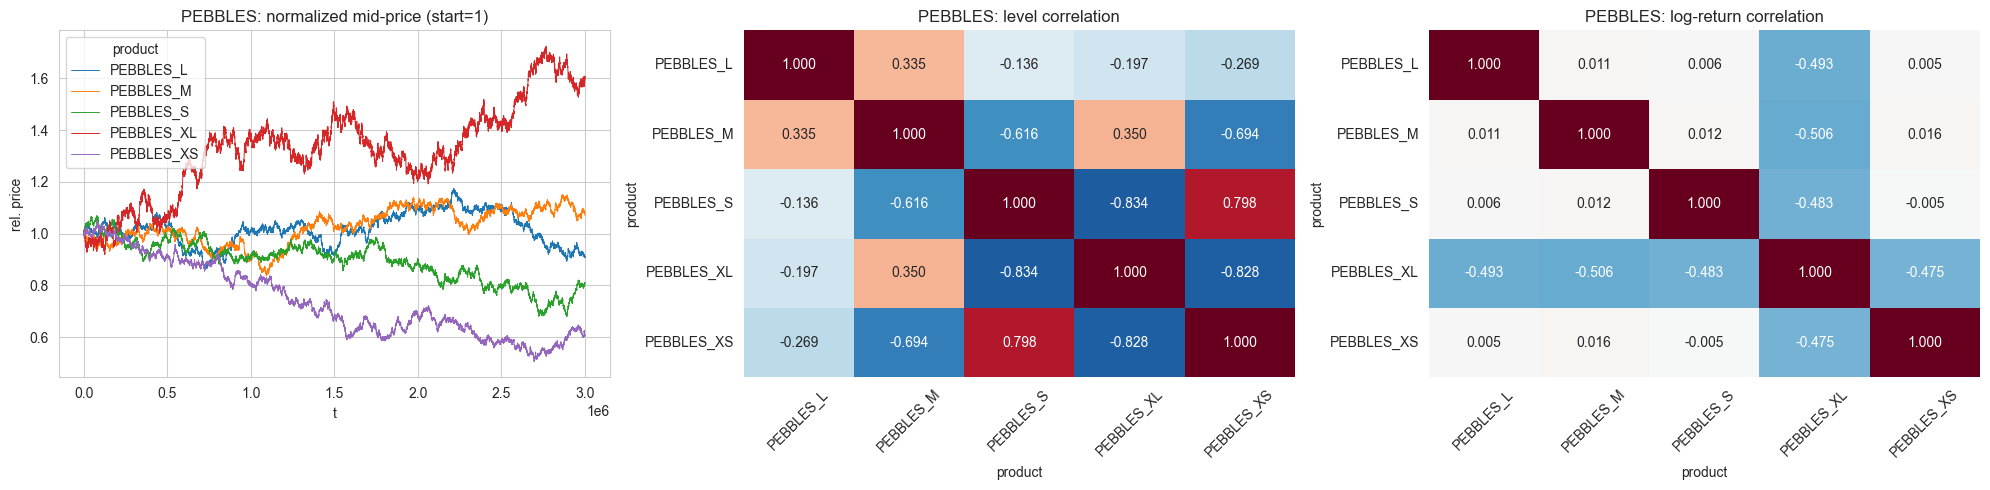

         a          b  level_corr  ret_corr  spread_mean  spread_std  spread_adf_p  logspread_adf_p  stationary_5pct
 PEBBLES_L  PEBBLES_M      0.3354    0.0111     -89.1326    757.1418        0.1000           0.1000            False
 PEBBLES_L  PEBBLES_S     -0.1360    0.0065    1241.7539   1105.7754        0.1000           0.1000            False
 PEBBLES_L PEBBLES_XL     -0.1972   -0.4932   -3051.4787   1994.8726        0.1000           0.1000            False
 PEBBLES_L PEBBLES_XS     -0.2686    0.0050    2769.4708   1724.2397        0.1000           0.1000            False
 PEBBLES_M  PEBBLES_S     -0.6157    0.0116    1330.8864   1368.6633        0.1000           0.1000            False
 PEBBLES_M PEBBLES_XL      0.3505   -0.5059   -2962.3461   1665.1431        0.1000           0.1000            False
 PEBBLES_S PEBBLES_XL     -0.8344   -0.4829   -4293.2326   2514.1159        0.1000           0.1000            False
 PEBBLES_S PEBBLES_XS      0.7983   -0.0054    1527.7170    931.

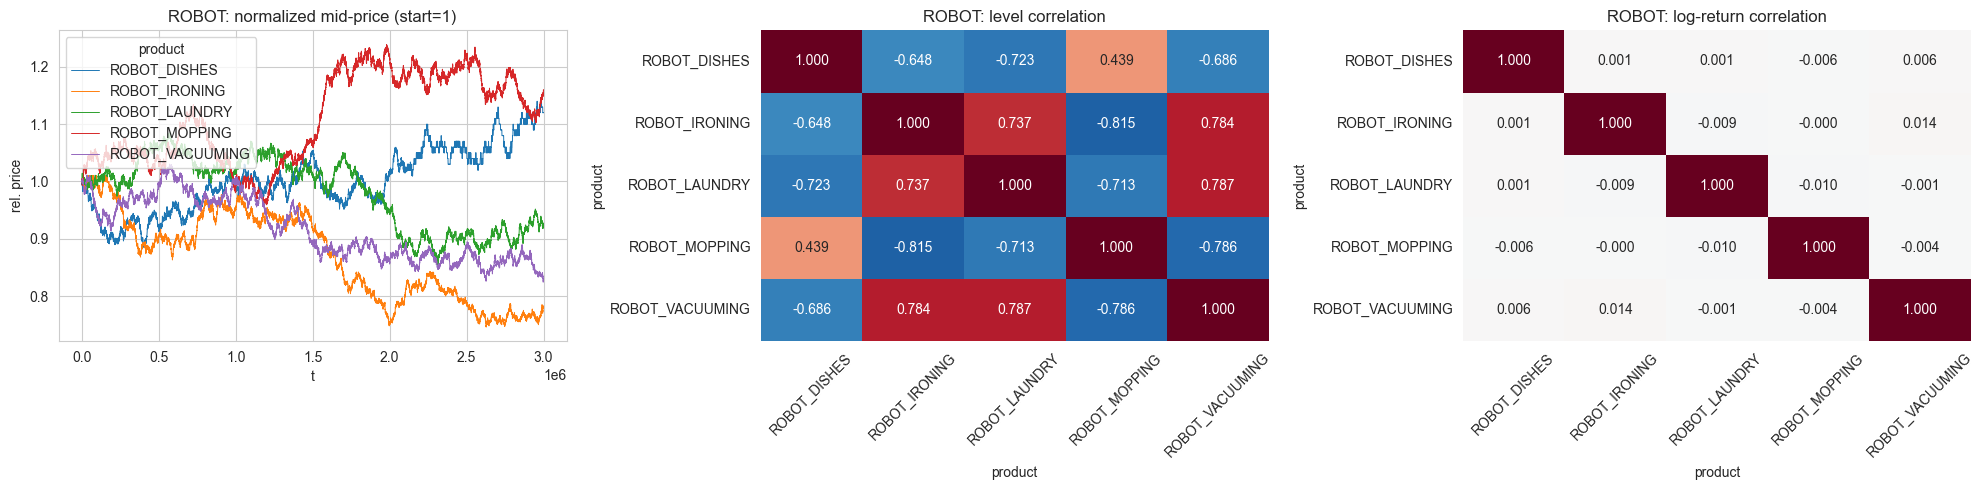

            a               b  level_corr  ret_corr  spread_mean  spread_std  spread_adf_p  logspread_adf_p  stationary_5pct
ROBOT_LAUNDRY ROBOT_VACUUMING      0.7874   -0.0014     655.9859    382.1710        0.0224           0.0240             True
ROBOT_IRONING   ROBOT_LAUNDRY      0.7371   -0.0090   -1121.1914    523.0381        0.0814           0.1000            False
 ROBOT_DISHES   ROBOT_MOPPING      0.4391   -0.0059   -1081.8983    723.4139        0.1000           0.1000            False
ROBOT_IRONING   ROBOT_MOPPING     -0.8152   -0.0003   -2398.6430   1465.3967        0.1000           0.1000            False
ROBOT_IRONING ROBOT_VACUUMING      0.7842    0.0138    -465.2055    483.4012        0.1000           0.1000            False
ROBOT_MOPPING ROBOT_VACUUMING     -0.7860   -0.0039    1933.4374   1233.1034        0.1000           0.1012            False
ROBOT_LAUNDRY   ROBOT_MOPPING     -0.7135   -0.0096   -1277.4515   1280.0104        0.1438           0.1421            False


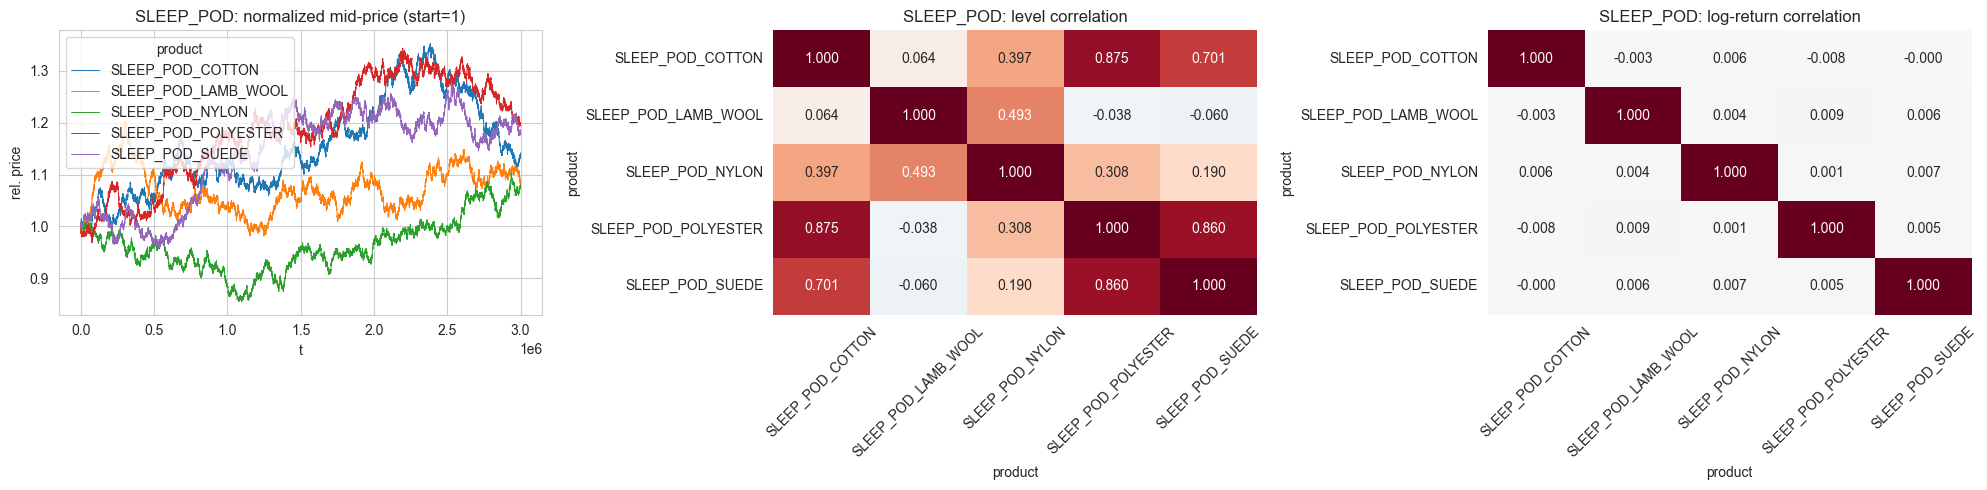

                  a                   b  level_corr  ret_corr  spread_mean  spread_std  spread_adf_p  logspread_adf_p  stationary_5pct
   SLEEP_POD_COTTON SLEEP_POD_POLYESTER      0.8752   -0.0076    -312.9470    473.9197        0.0379           0.0393             True
SLEEP_POD_POLYESTER     SLEEP_POD_SUEDE      0.8596    0.0053     443.1405    503.0114        0.0527           0.0499            False
SLEEP_POD_LAMB_WOOL     SLEEP_POD_NYLON      0.4932    0.0038    1064.9691    471.3729        0.0665           0.0845            False
   SLEEP_POD_COTTON SLEEP_POD_LAMB_WOOL      0.0641   -0.0031     826.1722    954.8333        0.1000           0.1000            False
   SLEEP_POD_COTTON     SLEEP_POD_NYLON      0.3974    0.0060    1891.1414    829.3591        0.1000           0.1000            False
   SLEEP_POD_COTTON     SLEEP_POD_SUEDE      0.7010   -0.0002     130.1935    691.3349        0.1000           0.1000            False
SLEEP_POD_LAMB_WOOL SLEEP_POD_POLYESTER     -0.0385    

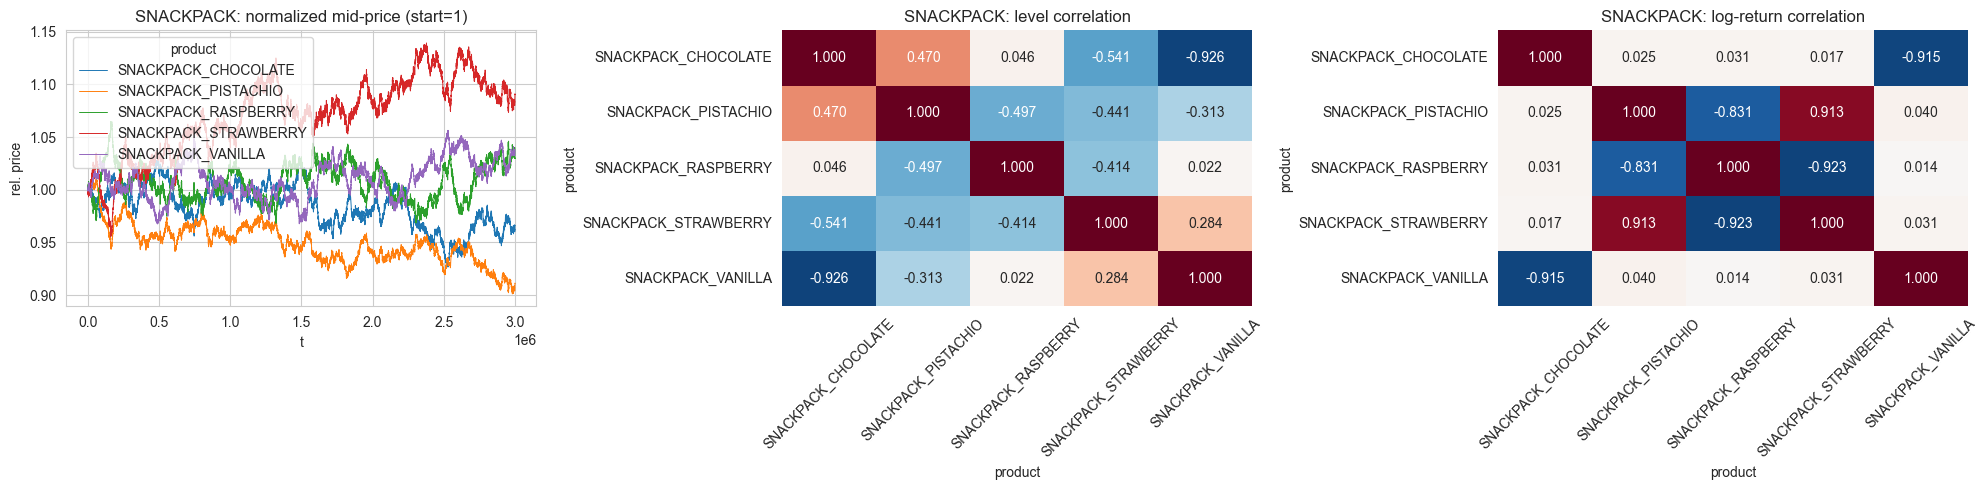

                   a                    b  level_corr  ret_corr  spread_mean  spread_std  spread_adf_p  logspread_adf_p  stationary_5pct
 SNACKPACK_CHOCOLATE  SNACKPACK_PISTACHIO      0.4704    0.0247     347.5277    200.0925        0.0050           0.0050             True
 SNACKPACK_PISTACHIO  SNACKPACK_RASPBERRY     -0.4974   -0.8307    -581.9682    309.2933        0.0050           0.0050             True
 SNACKPACK_RASPBERRY    SNACKPACK_VANILLA      0.0219    0.0145     -19.4904    243.6672        0.0050           0.0050             True
 SNACKPACK_CHOCOLATE  SNACKPACK_RASPBERRY      0.0461    0.0308    -234.4404    256.8834        0.0179           0.0172             True
 SNACKPACK_RASPBERRY SNACKPACK_STRAWBERRY     -0.4136   -0.9232    -628.7964    460.5373        0.0281           0.0281             True
 SNACKPACK_CHOCOLATE    SNACKPACK_VANILLA     -0.9259   -0.9152    -253.9308    372.1780        0.0490           0.0462             True
SNACKPACK_STRAWBERRY    SNACKPACK_VANILLA

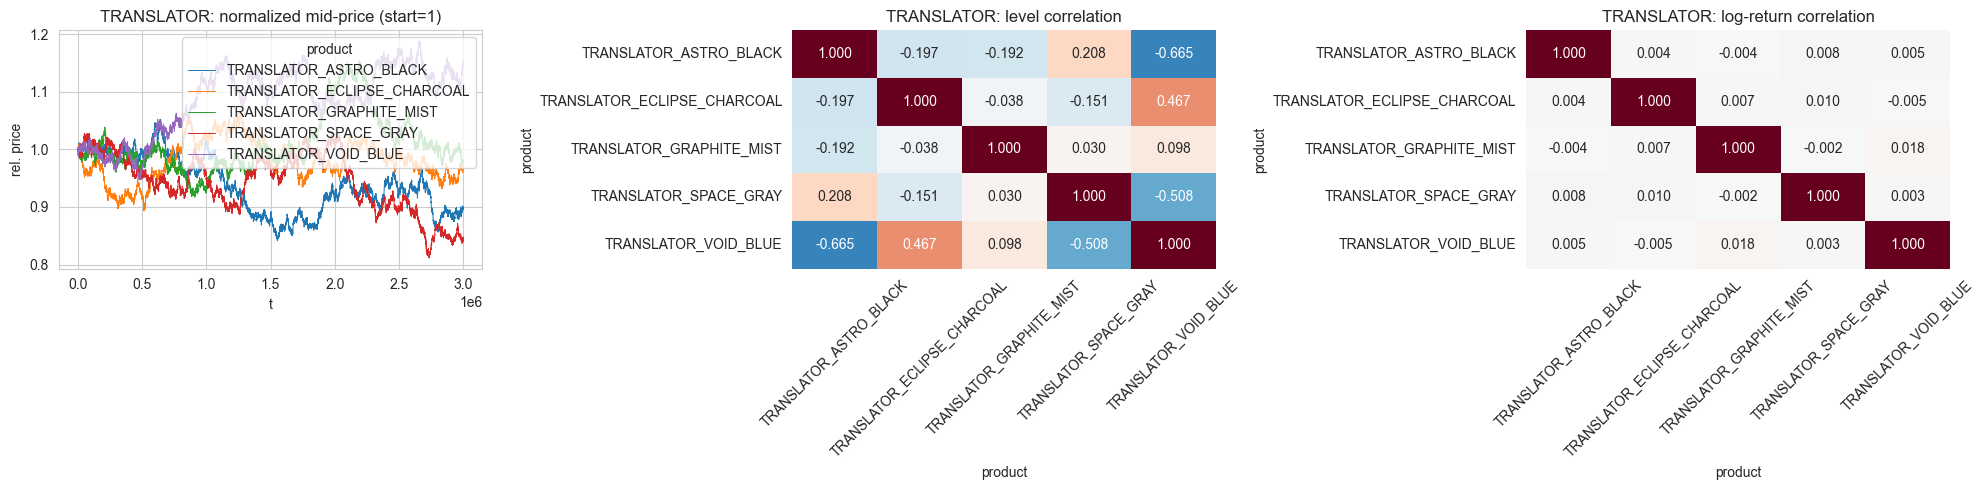

                          a                           b  level_corr  ret_corr  spread_mean  spread_std  spread_adf_p  logspread_adf_p  stationary_5pct
TRANSLATOR_ECLIPSE_CHARCOAL        TRANSLATOR_VOID_BLUE      0.4673   -0.0047   -1044.8374    519.1192        0.0941           0.0729            False
     TRANSLATOR_ASTRO_BLACK TRANSLATOR_ECLIPSE_CHARCOAL     -0.1968    0.0037    -428.5227    659.4691        0.1000           0.1000            False
     TRANSLATOR_ASTRO_BLACK    TRANSLATOR_GRAPHITE_MIST     -0.1924   -0.0035    -699.4205    763.9026        0.1000           0.1000            False
     TRANSLATOR_ASTRO_BLACK       TRANSLATOR_SPACE_GRAY      0.2077    0.0085     -46.6827    624.7306        0.1000           0.1000            False
     TRANSLATOR_ASTRO_BLACK        TRANSLATOR_VOID_BLUE     -0.6654    0.0048   -1473.3602    976.1776        0.1000           0.1000            False
TRANSLATOR_ECLIPSE_CHARCOAL    TRANSLATOR_GRAPHITE_MIST     -0.0375    0.0068    -270.8978    

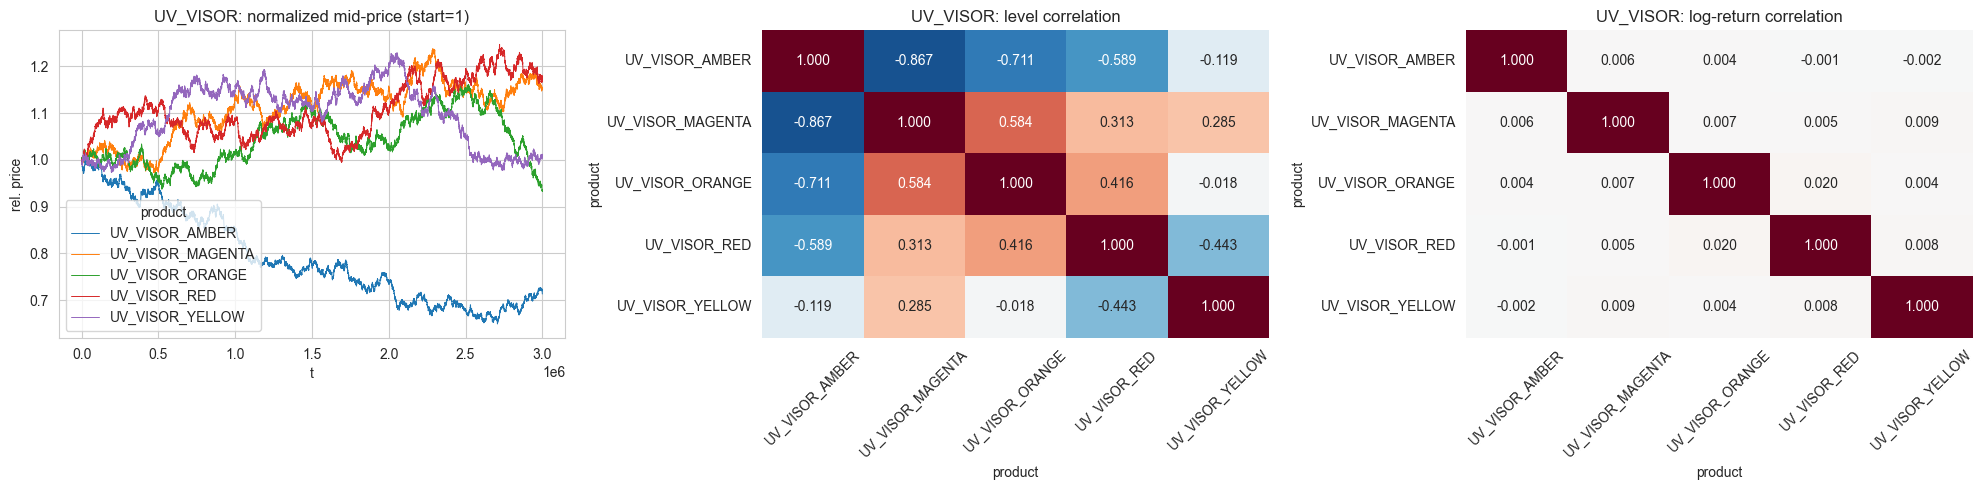

               a                b  level_corr  ret_corr  spread_mean  spread_std  spread_adf_p  logspread_adf_p  stationary_5pct
  UV_VISOR_AMBER UV_VISOR_MAGENTA     -0.8673    0.0062   -3200.0966   1559.2481        0.1000           0.1000            False
  UV_VISOR_AMBER  UV_VISOR_ORANGE     -0.7106    0.0043   -2514.8100   1441.2344        0.1000           0.1000            False
  UV_VISOR_AMBER     UV_VISOR_RED     -0.5886   -0.0012   -3151.5973   1424.4074        0.1000           0.1000            False
  UV_VISOR_AMBER  UV_VISOR_YELLOW     -0.1190   -0.0024   -3045.7645   1272.9959        0.1000           0.1000            False
UV_VISOR_MAGENTA  UV_VISOR_ORANGE      0.5844    0.0066     685.2867    533.6404        0.1000           0.1000            False
UV_VISOR_MAGENTA     UV_VISOR_RED      0.3128    0.0053      48.4993    704.4424        0.1000           0.1000            False
UV_VISOR_MAGENTA  UV_VISOR_YELLOW      0.2846    0.0094     154.3322    776.6786        0.1000   

In [6]:
group_results = {}
for g, members in GROUPS.items():
    print(f'\n=== {g} ===')
    pairs, lvl_corr, ret_corr = analyse_group(g, members, mid, log_ret)
    print(pairs.to_string(index=False))
    group_results[g] = {'pairs': pairs, 'lvl_corr': lvl_corr, 'ret_corr': ret_corr}

## 6. Cross-group summary: most stationary pairs

Best stationary spreads across all groups, ranked by ADF p-value. Pairs with p < 0.05 reject unit root and are good candidates for mean-reversion / pairs trading.

In [7]:
all_pairs = pd.concat(
    [r['pairs'].assign(group=g) for g, r in group_results.items()],
    ignore_index=True,
)
cols = ['group', 'a', 'b', 'level_corr', 'ret_corr',
        'spread_mean', 'spread_std', 'spread_adf_p', 'stationary_5pct']
print('Top 15 most stationary spreads (lowest ADF p):')
print(all_pairs.sort_values('spread_adf_p')[cols].head(15).to_string(index=False))
print()
print('Stationary pair counts per group (p < 0.05):')
print(all_pairs.groupby('group')['stationary_5pct'].sum().sort_values(ascending=False))

Top 15 most stationary spreads (lowest ADF p):
       group                           a                    b  level_corr  ret_corr  spread_mean  spread_std  spread_adf_p  stationary_5pct
   SNACKPACK         SNACKPACK_RASPBERRY    SNACKPACK_VANILLA      0.0219    0.0145     -19.4904    243.6672        0.0050             True
   SNACKPACK         SNACKPACK_PISTACHIO  SNACKPACK_RASPBERRY     -0.4974   -0.8307    -581.9682    309.2933        0.0050             True
   SNACKPACK         SNACKPACK_CHOCOLATE  SNACKPACK_PISTACHIO      0.4704    0.0247     347.5277    200.0925        0.0050             True
   SNACKPACK         SNACKPACK_CHOCOLATE  SNACKPACK_RASPBERRY      0.0461    0.0308    -234.4404    256.8834        0.0179             True
       ROBOT               ROBOT_LAUNDRY      ROBOT_VACUUMING      0.7874   -0.0014     655.9859    382.1710        0.0224             True
   SNACKPACK         SNACKPACK_RASPBERRY SNACKPACK_STRAWBERRY     -0.4136   -0.9232    -628.7964    460.5373     

## 7. Highest correlation pairs (level)

Independent of stationarity, these are the pairs that move most together — a starting point for further pair / basket strategies.

In [8]:
print('Top 15 by level correlation:')
print(all_pairs.sort_values('level_corr', ascending=False)[cols].head(15).to_string(index=False))
print()
print('Top 15 by log-return correlation:')
print(all_pairs.sort_values('ret_corr', ascending=False)[cols].head(15).to_string(index=False))

Top 15 by level correlation:
       group                           a                    b  level_corr  ret_corr  spread_mean  spread_std  spread_adf_p  stationary_5pct
   SLEEP_POD            SLEEP_POD_COTTON  SLEEP_POD_POLYESTER      0.8752   -0.0076    -312.9470    473.9197        0.0379             True
   MICROCHIP              MICROCHIP_OVAL   MICROCHIP_TRIANGLE      0.8705    0.0018   -1506.7924    922.7015        0.1000            False
   SLEEP_POD         SLEEP_POD_POLYESTER      SLEEP_POD_SUEDE      0.8596    0.0053     443.1405    503.0114        0.0527            False
     PEBBLES                   PEBBLES_S           PEBBLES_XS      0.7983   -0.0054    1527.7170    931.1863        0.1000            False
       ROBOT               ROBOT_LAUNDRY      ROBOT_VACUUMING      0.7874   -0.0014     655.9859    382.1710        0.0224             True
       ROBOT               ROBOT_IRONING      ROBOT_VACUUMING      0.7842    0.0138    -465.2055    483.4012        0.1000         

## 8. Heatmap of all 50 products (cross-group)

Big-picture view of which groups behave as a unit and whether there are any cross-group correlations worth investigating.

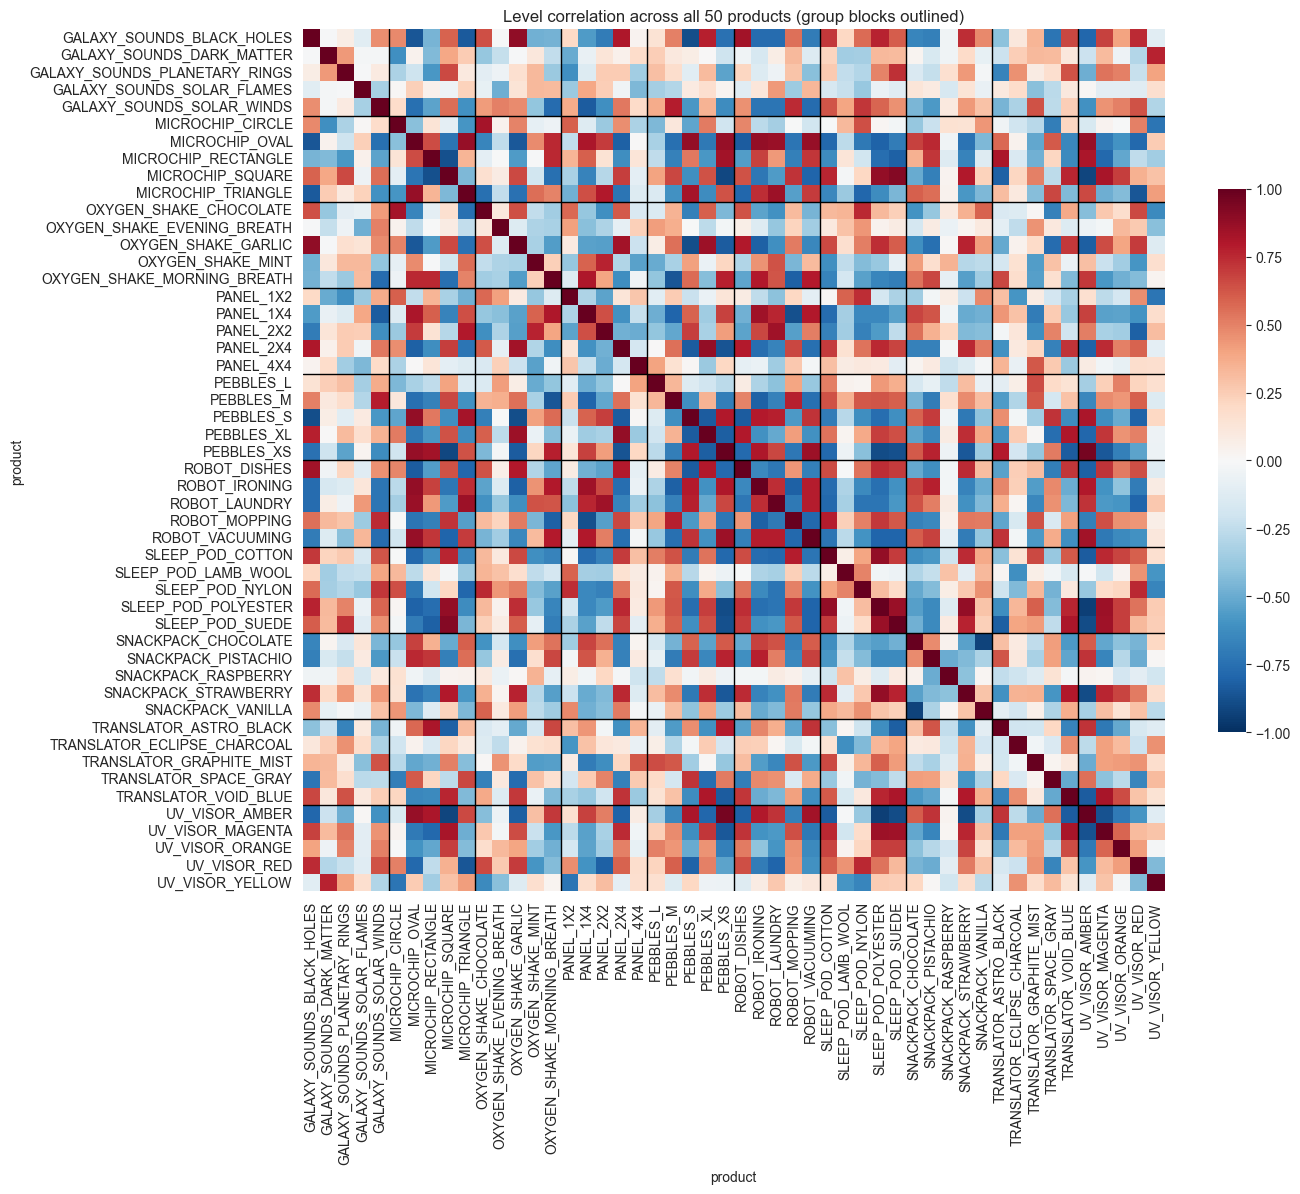

In [9]:
ordered = [p for g in GROUPS for p in GROUPS[g]]
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(mid[ordered].corr(), cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, xticklabels=True, yticklabels=True, ax=ax,
            cbar_kws={'shrink': 0.6})
# Draw group boundaries
boundaries = np.cumsum([len(GROUPS[g]) for g in GROUPS])[:-1]
for b in boundaries:
    ax.axhline(b, color='black', lw=1.0)
    ax.axvline(b, color='black', lw=1.0)
ax.set_title('Level correlation across all 50 products (group blocks outlined)')
plt.tight_layout(); plt.show()